<a href="https://colab.research.google.com/github/chirusainanda/Data-Cleaning/blob/main/Copy_of_Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [ ]:
df = pd.read_csv('train.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (9800, 18)

First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
print("=== Dataset Info ===")
df.info()

print("\n=== Statistical Summary ===")
df.describe(include='all')

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
count,9800.000000,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9789.000000,9800,9800,9800,9800,9800,9800.000000
unique,NaN,4922,1230,1326,4,793,793,3,1,529,49,NaN,4,1861,3,17,1849,NaN
top,NaN,CA-2018-100111,05/09/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN
freq,NaN,14,38,34,5859,35,35,5101,9800,891,1946,NaN,3140,19,5909,1492,47,NaN
mean,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55273.322403,NaN,NaN,NaN,NaN,NaN,230.769059
std,2829.160653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32041.223413,NaN,NaN,NaN,NaN,NaN,626.651875
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000
25%,2450.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23223.000000,NaN,NaN,NaN,NaN,NaN,17.248000
50%,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58103.000000,NaN,NaN,NaN,NaN,NaN,54.490000
75%,7350.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90008.000000,NaN,NaN,NaN,NaN,NaN,210.605000


=== Missing Values ===
             Missing Count  Missing %
Postal Code             11       0.11


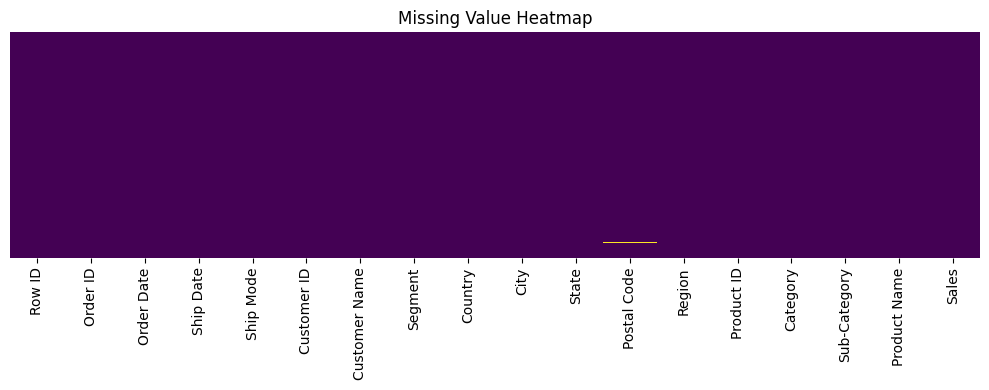

In [ ]:
print("=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
})
print(missing_df[missing_df['Missing Count'] > 0])

# Visualise missing values
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Value Heatmap')
plt.tight_layout()
plt.show()


In [ ]:
print(f"Total duplicate rows: {df.duplicated().sum()}")

Total duplicate rows: 0


In [ ]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('-', '_')
)
print("Renamed columns:", df.columns.tolist())

Renamed columns: ['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales']


In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)
df['ship_date']  = pd.to_datetime(df['ship_date'],  dayfirst=True)

In [ ]:
df['postal_code'] = df['postal_code'].astype('Int64').astype(str)
df['postal_code'] = df['postal_code'].replace('<NA>', np.nan)

In [ ]:
df['row_id'] = df['row_id'].astype(int)

print("Updated dtypes:")
print(df.dtypes)

Updated dtypes:
row_id                    int64
order_id                 object
order_date       datetime64[ns]
ship_date        datetime64[ns]
ship_mode                object
customer_id              object
customer_name            object
segment                  object
country                  object
city                     object
state                    object
postal_code              object
region                   object
product_id               object
category                 object
sub_category             object
product_name             object
sales                   float64
dtype: object


In [ ]:
print("Missing before fix:\n", df.isnull().sum()[df.isnull().sum() > 0])

Missing before fix:
 postal_code    11
dtype: int64


In [ ]:
df['postal_code'] = df['postal_code'].fillna('Unknown')

print("\nMissing after fix:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("✅ No more missing values!")


Missing after fix:
 Series([], dtype: int64)
✅ No more missing values!


In [ ]:
text_cols = ['ship_mode', 'segment', 'country', 'city',
             'state', 'region', 'category', 'sub_category']

for col in text_cols:
    df[col] = df[col].str.strip().str.title()

# Check unique values for key categorical columns
for col in ['ship_mode', 'segment', 'region', 'category']:
    print(f"\n{col}: {df[col].unique()}")


ship_mode: ['Second Class' 'Standard Class' 'First Class' 'Same Day']

segment: ['Consumer' 'Corporate' 'Home Office']

region: ['South' 'West' 'Central' 'East']

category: ['Furniture' 'Office Supplies' 'Technology']


In [ ]:
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"Duplicates removed: {before - after} | Rows remaining: {after}")

Duplicates removed: 0 | Rows remaining: 9800


Outliers in 'sales': 1145


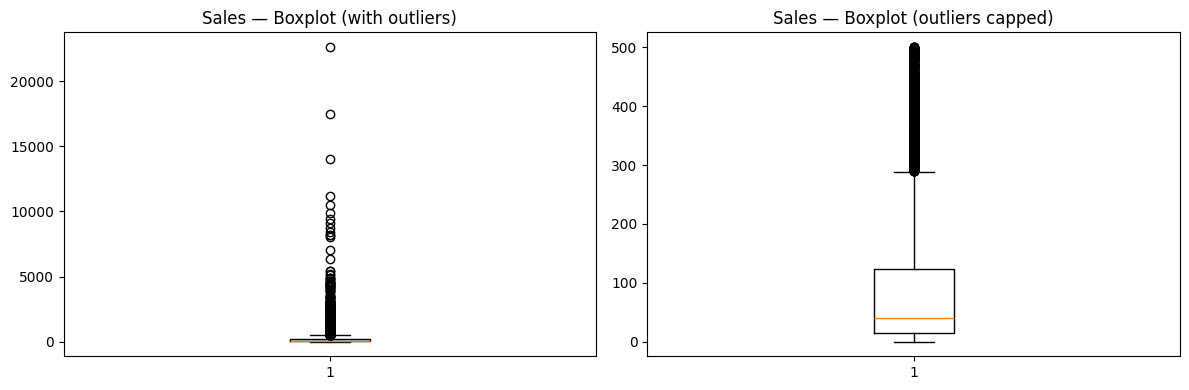

✅ Outliers capped.


In [ ]:
Q1 = df['sales'].quantile(0.25)
Q3 = df['sales'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['sales'] < lower) | (df['sales'] > upper)]
print(f"Outliers in 'sales': {len(outliers)}")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(df['sales'])
axes[0].set_title('Sales — Boxplot (with outliers)')
axes[1].boxplot(df[df['sales'] <= upper]['sales'])
axes[1].set_title('Sales — Boxplot (outliers capped)')
plt.tight_layout()
plt.show()

# Cap outliers using IQR method (Winsorization)
df['sales'] = df['sales'].clip(lower=lower, upper=upper)
print("✅ Outliers capped.")

In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True, errors='coerce')
df['ship_date']  = pd.to_datetime(df['ship_date'],  dayfirst=True, errors='coerce')

# Check conversion worked
print("order_date dtype:", df['order_date'].dtype)
print("ship_date dtype :", df['ship_date'].dtype)

# Calculate shipping days
df['shipping_days'] = (df['ship_date'] - df['order_date']).dt.days

print("\nShipping days stats:")
print(df['shipping_days'].describe())

order_date dtype: datetime64[ns]
ship_date dtype : datetime64[ns]

Shipping days stats:
count    9800.000000
mean        3.961122
std         1.749614
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: shipping_days, dtype: float64


In [ ]:
print("=== Final Dataset Info ===")
df.info()
print("\nMissing values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())
print("Shape:", df.shape)
df.head()

=== Final Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   row_id         9800 non-null   int64         
 1   order_id       9800 non-null   object        
 2   order_date     9800 non-null   datetime64[ns]
 3   ship_date      9800 non-null   datetime64[ns]
 4   ship_mode      9800 non-null   object        
 5   customer_id    9800 non-null   object        
 6   customer_name  9800 non-null   object        
 7   segment        9800 non-null   object        
 8   country        9800 non-null   object        
 9   city           9800 non-null   object        
 10  state          9800 non-null   object        
 11  postal_code    9800 non-null   object        
 12  region         9800 non-null   object        
 13  product_id     9800 non-null   object        
 14  category       9800 non-null   object        

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub_category,product_name,sales,shipping_days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",500.6405,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,500.6405,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,7


In [ ]:
df.to_csv('train_cleaned.csv', index=False)
print("✅ Cleaned dataset saved as 'train_cleaned.csv'")

✅ Cleaned dataset saved as 'train_cleaned.csv'


In [ ]:
files.download('train_cleaned.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
summary = """
╔══════════════════════════════════════════════════════╗
║         DATA CLEANING SUMMARY — SALES DATASET       ║
╠══════════════════════════════════════════════════════╣
║ 1. Renamed all columns → lowercase with underscores ║
║ 2. Converted order_date & ship_date → datetime      ║
║ 3. Fixed postal_code dtype → string (ZIP safe)      ║
║ 4. Filled 11 missing postal_code values → 'Unknown' ║
║ 5. Standardized text columns → Title Case + strip   ║
║ 6. Removed duplicate rows (0 found in this data)    ║
║ 7. Detected & capped sales outliers (IQR method)    ║
║ 8. Engineered new column: shipping_days             ║
║ Final shape: 9800 rows × 19 columns                 ║
╚══════════════════════════════════════════════════════╝
"""
print(summary)


╔══════════════════════════════════════════════════════╗
║         DATA CLEANING SUMMARY — SALES DATASET       ║
╠══════════════════════════════════════════════════════╣
║ 1. Renamed all columns → lowercase with underscores ║
║ 2. Converted order_date & ship_date → datetime      ║
║ 3. Fixed postal_code dtype → string (ZIP safe)      ║
║ 4. Filled 11 missing postal_code values → 'Unknown' ║
║ 5. Standardized text columns → Title Case + strip   ║
║ 6. Removed duplicate rows (0 found in this data)    ║
║ 7. Detected & capped sales outliers (IQR method)    ║
║ 8. Engineered new column: shipping_days             ║
║ Final shape: 9800 rows × 19 columns                 ║
╚══════════════════════════════════════════════════════╝

